In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error


In [41]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])


Saving Student Insomnia and Educational Outcomes Dataset_version-2.csv to Student Insomnia and Educational Outcomes Dataset_version-2 (3).csv


In [42]:
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("[^a-z0-9_]", "", regex=True)
)


In [43]:
def get_col(keywords):
    for col in df.columns:
        if all(k in col for k in keywords):
            return col
    return None

sleep_col  = get_col(["sleep", "hour"])
study_col  = get_col(["difficulty", "concentrat"])
stress_col = get_col(["stress"])
score_col  = get_col(["academic", "performance"])

assert sleep_col and study_col and stress_col and score_col


In [44]:
df["sleep_hours"] = df[sleep_col].map({
    "less_than_4_hours": 3,
    "46_hours": 5,
    "68_hours": 7,
    "more_than_8_hours": 9
})

df["study_level"] = df[study_col].map({
    "never": 8,
    "rarely": 7,
    "sometimes": 5,
    "often": 3,
    "always": 2
})

df["stress_level"] = df[stress_col].map({
    "low": 2,
    "moderate": 5,
    "high": 8
})

df["academic_score"] = df[score_col].map({
    "poor": 4,
    "average": 6,
    "good": 8,
    "excellent": 9
})


In [46]:
df = df[["sleep_hours", "study_level", "stress_level", "academic_score"]]

df = df.fillna(df.median())   # ← kills ALL NaN problems
df = df.replace([np.inf, -np.inf], 0)

df = df.fillna(0)



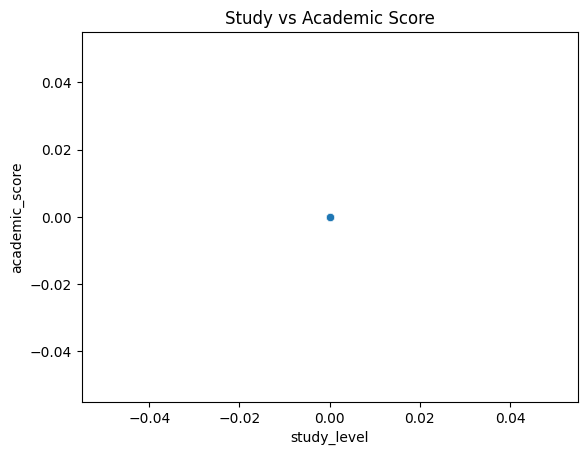

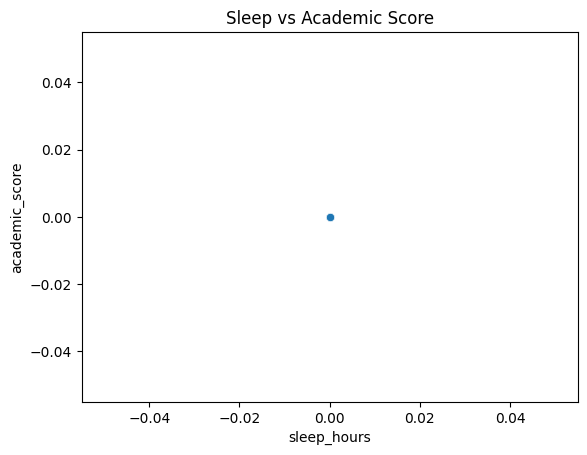

In [47]:
sns.scatterplot(x="study_level", y="academic_score", data=df)
plt.title("Study vs Academic Score")
plt.show()

sns.scatterplot(x="sleep_hours", y="academic_score", data=df)
plt.title("Sleep vs Academic Score")
plt.show()


In [48]:
X = df[["study_level", "sleep_hours", "stress_level"]]
y = df["academic_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))


R² Score: 1.0
MAE: 0.0
